In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q '/content/drive/MyDrive/Audio Dataset/CAT_DATASET_INFOSYS.zip' -d '/content/drive/MyDrive/Audio Dataset/extracted_folder'

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [5]:
DATA_DIR = "/content/drive/MyDrive/Audio Dataset/extracted_folder"   # change if needed
IMG_SIZE = 224         # standard for ResNet / EfficientNet
BATCH_SIZE = 16
NUM_WORKERS = 2


In [27]:
train_transforms = transforms.Compose([
    # 1️⃣ Pad image by reflection (kills black borders forever)
    transforms.Pad(
        padding=20,
        padding_mode="reflect"
    ),

    # 2️⃣ Small rotation ONLY
    transforms.RandomRotation(
        degrees=7,
        interpolation=transforms.InterpolationMode.BILINEAR
    ),

    # 3️⃣ Resize back to model input
    transforms.Resize((224, 224)),

    # 4️⃣ Horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # 5️⃣ Light color variation
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    # 6️⃣ Tensor + normalize
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [28]:
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [29]:
train_dataset = datasets.ImageFolder(
    root=f"{DATA_DIR}/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=f"{DATA_DIR}/val",
    transform=val_transforms
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


Classes: ['Angry', 'Disgusted', 'Happy', 'Normal', 'Sad', 'Scared', 'Surprised']
Number of classes: 7


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


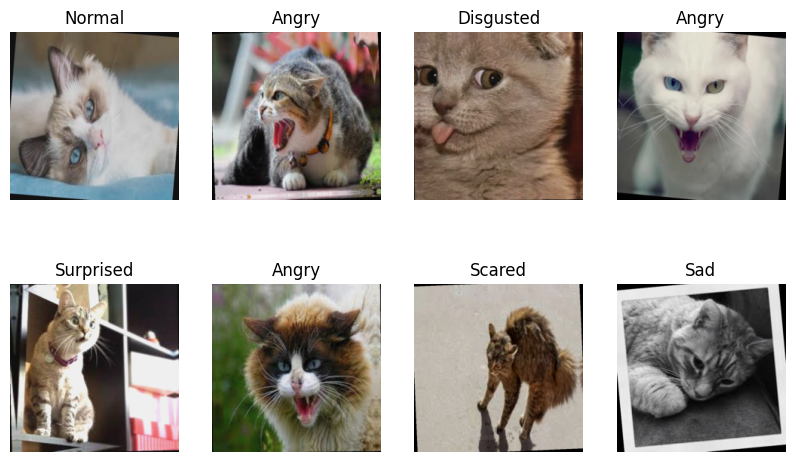

In [31]:
def show_batch(images, labels):
    images = images.permute(0, 2, 3, 1)
    images = images * torch.tensor([0.229, 0.224, 0.225]) + \
             torch.tensor([0.485, 0.456, 0.406])
    images = images.numpy()

    plt.figure(figsize=(10, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.clip(images[i], 0, 1))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
show_batch(images, labels)


In [32]:
import torch
import torch.nn as nn
import torchvision.models as models


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [34]:
model = models.resnet18(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s] 


In [35]:
for param in model.parameters():
    param.requires_grad = False


In [36]:
num_classes = 7  # Angry, Disgusted, Happy, Normal, Sad, Scared, Surprised

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)


In [37]:
model = model.to(device)


In [38]:
x = torch.randn(1, 3, 224, 224).to(device)
y = model(x)
print("Output shape:", y.shape)


Output shape: torch.Size([1, 7])


In [39]:
from collections import Counter

targets = [label for _, label in train_dataset.samples]
class_count = Counter(targets)

num_classes = len(class_count)

class_weights = torch.tensor(
    [1.0 / class_count[i] for i in range(num_classes)],
    dtype=torch.float
)

class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

print("Class weights:", class_weights)


Class weights: tensor([0.1432, 0.1643, 0.1643, 0.1355, 0.1591, 0.1269, 0.1066],
       device='cuda:0')


In [40]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


In [41]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)


In [42]:
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")


Trainable params: 3591
Total params: 11180103


In [43]:
EPOCHS = 30
PATIENCE = 5          # early stopping patience
best_val_loss = float("inf")
patience_counter = 0


In [44]:
def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)


In [46]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 30)

    # =====================
    # 🔥 Training Phase
    # =====================
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(outputs, labels)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = running_acc / len(train_loader)

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # =====================
    # 🧪 Validation Phase
    # =====================
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += accuracy_from_logits(outputs, labels)

    epoch_val_loss = running_loss / len(val_loader)
    epoch_val_acc = running_acc / len(val_loader)

    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    # =====================
    # 📈 Logging
    # =====================
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")

    # =====================
    # ⏹️ Early Stopping
    # =====================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_cat_emotion_model.pth")
        print("✅ Best model saved")

    else:
        patience_counter += 1
        print(f"⚠️ No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("⛔ Early stopping triggered")
            break



Epoch [1/30]
------------------------------
Train Loss: 1.9595 | Train Acc: 0.2122
Val   Loss: 1.8485 | Val   Acc: 0.2835
✅ Best model saved

Epoch [2/30]
------------------------------
Train Loss: 1.6570 | Train Acc: 0.4128
Val   Loss: 1.6657 | Val   Acc: 0.3447
✅ Best model saved

Epoch [3/30]
------------------------------
Train Loss: 1.5170 | Train Acc: 0.4674
Val   Loss: 1.5608 | Val   Acc: 0.4413
✅ Best model saved

Epoch [4/30]
------------------------------
Train Loss: 1.4089 | Train Acc: 0.5527
Val   Loss: 1.5611 | Val   Acc: 0.4211
⚠️ No improvement (1/5)

Epoch [5/30]
------------------------------
Train Loss: 1.3146 | Train Acc: 0.5677
Val   Loss: 1.3522 | Val   Acc: 0.5492
✅ Best model saved

Epoch [6/30]
------------------------------
Train Loss: 1.2698 | Train Acc: 0.5918
Val   Loss: 1.4516 | Val   Acc: 0.4937
⚠️ No improvement (1/5)

Epoch [7/30]
------------------------------
Train Loss: 1.1661 | Train Acc: 0.6452
Val   Loss: 1.4115 | Val   Acc: 0.5221
⚠️ No improveme

In [47]:
model.load_state_dict(torch.load("best_cat_emotion_model.pth"))
print("Best model loaded successfully")


Best model loaded successfully


In [48]:
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns


In [49]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


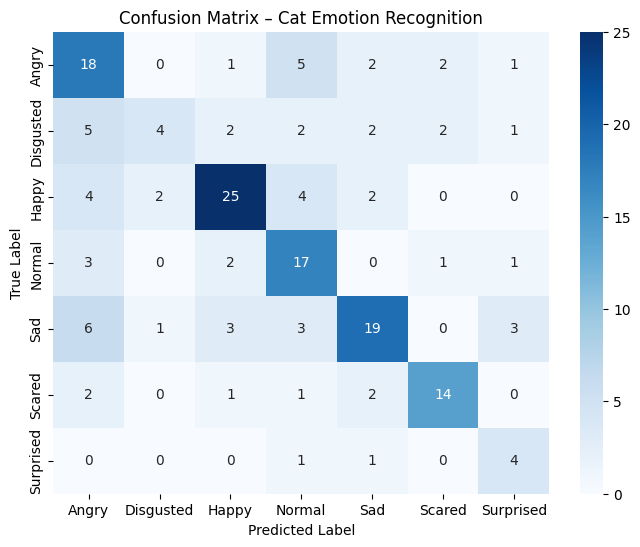

In [50]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Cat Emotion Recognition")
plt.show()


In [51]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

       Angry     0.4737    0.6207    0.5373        29
   Disgusted     0.5714    0.2222    0.3200        18
       Happy     0.7353    0.6757    0.7042        37
      Normal     0.5152    0.7083    0.5965        24
         Sad     0.6786    0.5429    0.6032        35
      Scared     0.7368    0.7000    0.7179        20
   Surprised     0.4000    0.6667    0.5000         6

    accuracy                         0.5976       169
   macro avg     0.5873    0.5909    0.5685       169
weighted avg     0.6182    0.5976    0.5928       169



In [52]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Macro F1-score:", round(macro_f1, 4))


Macro F1-score: 0.5685


In [53]:
# Freeze everything first (safety)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True

# Also keep classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True


In [54]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")


Trainable params: 8397319
Total params: 11180103


In [55]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4   # 🔴 LOWER than before
)


In [56]:
EPOCHS = 20          # fewer epochs
PATIENCE = 5
best_val_loss = float("inf")
patience_counter = 0


In [57]:
for epoch in range(EPOCHS):
    print(f"\nFine-tune Epoch [{epoch+1}/{EPOCHS}]")
    print("-" * 35)

    # 🔥 Training
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += (outputs.argmax(1) == labels).float().mean().item()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # 🧪 Validation
    model.eval()
    val_loss, val_acc = 0.0, 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_acc += (outputs.argmax(1) == labels).float().mean().item()

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # ⏹️ Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_finetuned_model.pth")
        print("✅ Best fine-tuned model saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("⛔ Early stopping triggered")
            break



Fine-tune Epoch [1/20]
-----------------------------------
Train Loss: 1.0247 | Train Acc: 0.6465
Val   Loss: 1.0722 | Val   Acc: 0.6402
✅ Best fine-tuned model saved

Fine-tune Epoch [2/20]
-----------------------------------
Train Loss: 0.4790 | Train Acc: 0.8607
Val   Loss: 1.0164 | Val   Acc: 0.6269
✅ Best fine-tuned model saved

Fine-tune Epoch [3/20]
-----------------------------------
Train Loss: 0.3089 | Train Acc: 0.9180
Val   Loss: 0.9860 | Val   Acc: 0.6742
✅ Best fine-tuned model saved

Fine-tune Epoch [4/20]
-----------------------------------
Train Loss: 0.1718 | Train Acc: 0.9785
Val   Loss: 1.0303 | Val   Acc: 0.6427
⚠️ No improvement (1/5)

Fine-tune Epoch [5/20]
-----------------------------------
Train Loss: 0.1393 | Train Acc: 0.9805
Val   Loss: 0.9954 | Val   Acc: 0.6698
⚠️ No improvement (2/5)

Fine-tune Epoch [6/20]
-----------------------------------
Train Loss: 0.0943 | Train Acc: 0.9850
Val   Loss: 1.0575 | Val   Acc: 0.6484
⚠️ No improvement (3/5)

Fine-tune

In [58]:
model.load_state_dict(torch.load("best_finetuned_model.pth"))
print("Best fine-tuned model loaded")


Best fine-tuned model loaded


In [59]:
model.load_state_dict(torch.load("best_finetuned_model.pth"))
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [60]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [61]:
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns


In [62]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


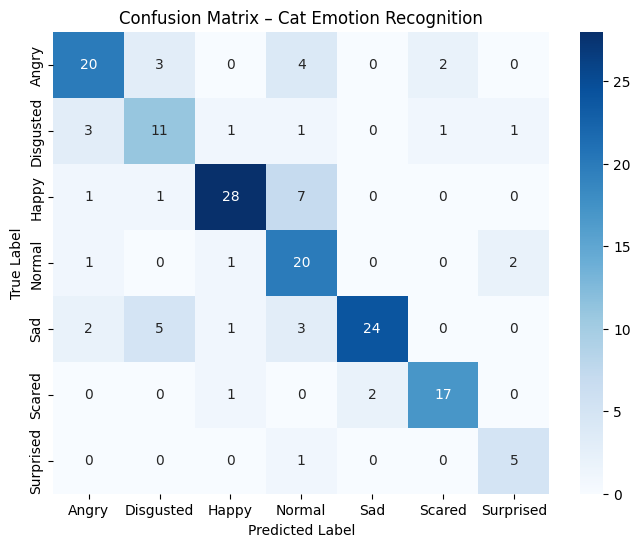

In [63]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Cat Emotion Recognition")
plt.show()


In [64]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

       Angry     0.7407    0.6897    0.7143        29
   Disgusted     0.5500    0.6111    0.5789        18
       Happy     0.8750    0.7568    0.8116        37
      Normal     0.5556    0.8333    0.6667        24
         Sad     0.9231    0.6857    0.7869        35
      Scared     0.8500    0.8500    0.8500        20
   Surprised     0.6250    0.8333    0.7143         6

    accuracy                         0.7396       169
   macro avg     0.7313    0.7514    0.7318       169
weighted avg     0.7701    0.7396    0.7455       169



In [65]:



macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Macro F1-score:", round(macro_f1, 4))


Macro F1-score: 0.7318


Saving 49_a_jpeg.rf.044cb9087ca07a62b63f2adcd505d147.jpg to 49_a_jpeg.rf.044cb9087ca07a62b63f2adcd505d147.jpg


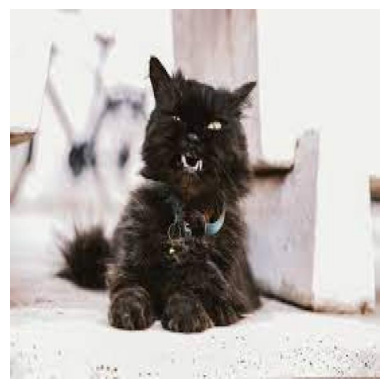

Predicted Emotion: Angry
Confidence: 0.81


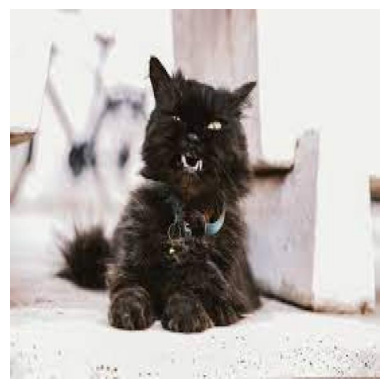

Predicted Emotion: Angry
Confidence: 0.81


In [83]:
from google.colab import files

uploaded = files.upload()   # choose a cat image

class_names = [
    "Angry",
    "Disgusted",
    "Happy",
    "Normal",
    "Sad",
    "Scared",
    "Surprised"
]
from torchvision import transforms
from PIL import Image

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 7)

model.load_state_dict(
    torch.load("/content/best_finetuned_model.pth", map_location=device)
)

model = model.to(device)
model.eval()
import matplotlib.pyplot as plt

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")

# Show image
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocess
image_tensor = infer_transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(image_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()

predicted_emotion = class_names[pred_idx]
confidence = probs[0][pred_idx].item()

print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence: {confidence:.2f}")
import matplotlib.pyplot as plt

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Load image
image = Image.open(image_path).convert("RGB")

# Show image
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocess
image_tensor = infer_transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(image_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()

predicted_emotion = class_names[pred_idx]
confidence = probs[0][pred_idx].item()

print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence: {confidence:.2f}")
